In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
with open('../data/names.txt') as f:
    names = f.read().splitlines()

In [3]:
charset = ['.'] + sorted(list(set(''.join(names))))
stoi = { char: index for index, char in enumerate(charset)}
itos = { index: char for char, index in stoi.items() }

In [4]:
# create the dataset
def build_dataset(words, block_size):

    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            Y.append(ix)
            X.append(context)
            context = context[1:] + [ix]

    XS, YS = torch.tensor(X), torch.tensor(Y)
    return XS, YS

In [12]:
block_size = 3
embedding_dim = 6
vocab_size = 27
hidden_layer_size = 100
epochs = 20000
batch_size = 32

training_split = 0.8
validation_split = 0.1
test_split = 0.1

In [13]:
rng = torch.Generator().manual_seed(2147483647)

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [14]:
import random
data_size = len(names)
random.shuffle(names)
s1 = int(training_split * data_size)
s2 = int((training_split + validation_split) * data_size)

Xtr, ytr = build_dataset(names[:s1], block_size=block_size)
Xdev, ydev = build_dataset(names[s1:s2], block_size=block_size)
Xtest, ytest = build_dataset(names[s2:], block_size=block_size)


In [15]:
C = torch.randn(size=(vocab_size, embedding_dim), generator=rng)
W1 = torch.randn(size=(embedding_dim * block_size, hidden_layer_size), generator=rng)
b1 = torch.randn(size=(hidden_layer_size, ), generator=rng)
W2 = torch.randn(size=(hidden_layer_size, vocab_size), generator=rng)
b2 = torch.randn(size=(vocab_size, ), generator=rng)
parameters = [C, W1, b1, W2, b2]

print(f'no of parameters: {sum(p.nelement() for p in parameters)}')

no of parameters: 4789


In [16]:
for p in parameters:
    p.requires_grad = True

In [17]:
lossi = []
stepi = []

for epoch in range(epochs):
    
    batch = torch.randint(0, len(Xtr), size=(batch_size, ), generator=rng)
    # fwd prop
    emb = C[Xtr[batch]]
    h = torch.tanh(emb.view(-1, embedding_dim*block_size) @ W1 + b1)
    logits = h @ W2 + b2
    counts = logits.exp()
    ypred = counts / counts.sum(dim=1, keepdim=True)

    # loss
    loss = -ypred[torch.arange(batch_size), ytr[batch]].log().mean()

    # bwd propogation
    for p in parameters:
        p.grad = None
    loss.backward()

    # update params
    lr = 0.1 if epoch < 10000 else 0.01 # learning rate decay
    for p in parameters:
        p.data = p.data - lr * p.grad

    lossi.append(loss.log10().item())
    stepi.append(epoch)
    # print(f'epoch: {epoch} | loss = {loss.item():.4f}')


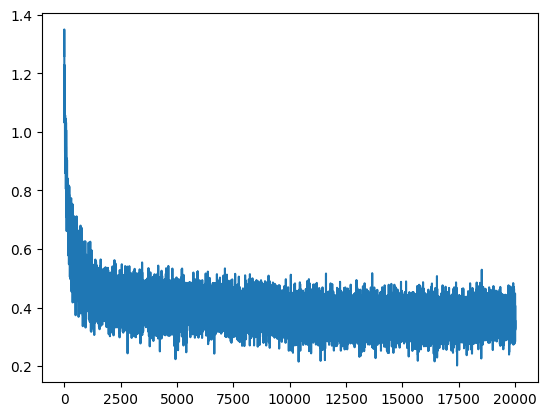

In [18]:
plt.plot(stepi, lossi)